# HydroSense-Kenya — Level 6
**ICS 2207 Scientific Computing**

Level 6: Final Integration, Testing, Reproducibility, and Scientific Communication

## Overview

This is the final integration notebook. It imports and calls functions from all five src modules, runs the complete workflow from raw data to optimized irrigation decision, and produces a final summary visualization. All code has been tested using pytest.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')

from src.data_cleaning import clean_weather, clean_soil
from src.numerical_methods import bisection, gaussian_elimination, trapezoidal
from src.simulation import euler_simulation, rk4_simulation
from src.optimization import optimize_irrigation
from src.visualization import plot_soil_moisture, plot_irrigation_schedule

import warnings
warnings.filterwarnings('ignore')
print('all modules imported')

all modules imported


## Step 1 — Load and Clean Data

In [2]:
weather = pd.read_csv('../data/raw/weather_daily.csv', na_values=['NA', ''])
soil    = pd.read_csv('../data/raw/soil_sensor_data.csv', na_values=['NA', ''])
params  = pd.read_csv('../data/raw/crop_zone_parameters.csv', na_values=['NA', ''])
weather['date'] = pd.to_datetime(weather['date'])

weather_clean, weather_log = clean_weather(weather)
soil_clean, soil_log = clean_soil(soil)

print('cleaning complete')
for entry in weather_log + soil_log:
    print(' -', entry)

cleaning complete
 - rainfall_mm: 1 missing value imputed with median 3.0 mm (Mar 8)
 - humidity_pct: 1 missing value imputed with median 65.1% (Mar 21)
 - temperature_c: outlier 45.8C on Mar 14 capped at 40.0C (not physically realistic for Nairobi in March)
 - soil_moisture_pct: 1 missing value imputed with median 27.5% (Zone_B Mar 6)
 - tank_level_liters: value of 9900L on Zone_C Mar 14 capped at 6000L (exceeds physical tank capacity)
 - soil_moisture_pct: 1 value(s) below 10% replaced with median (likely sensor fault, Zone_B Mar 25)


## Step 2 — Compute ET

In [3]:
et_series = np.maximum(
    0,
    0.12*weather_clean['temperature_c'].values
    + 0.35*weather_clean['wind_speed_mps'].values
    + 2.4*weather_clean['solar_index'].values
    - 0.025*weather_clean['humidity_pct'].values
)
rainfall = weather_clean['rainfall_mm'].values

print('mean ET:', round(et_series.mean(), 3), 'mm/day')
print('total rainfall:', round(rainfall.sum(), 2), 'mm')

mean ET: 3.721 mm/day
total rainfall: 250.4 mm


## Step 3 — Root Finding: Required Irrigation for Zone A

In [4]:
S_current = 22.60
S_target  = 33.0
ET_today  = et_series[-1]
R_today   = rainfall[-1]

def irrigation_needed(I):
    S_next = S_current + R_today + I - ET_today
    D = 0.18 * max(0, S_next - 41.0)
    return S_next - D - S_target

root, iters, err, converged, _ = bisection(irrigation_needed, 0, 30)
print('irrigation needed to reach target:', round(root, 2), 'mm')
print('bisection converged in', iters, 'iterations')

irrigation needed to reach target: 13.32 mm
bisection converged in 24 iterations


## Step 4 — Simulation

In [5]:
zone_a_params = {
    'drainage_coefficient': 0.18,
    'field_capacity_pct': 41.0,
    'min_moisture_pct': 22.0,
    'S0': 33.20
}

irr_zero = np.zeros(30)
S_euler = euler_simulation(zone_a_params['S0'], rainfall, et_series, irr_zero, zone_a_params)
S_rk4   = rk4_simulation(zone_a_params['S0'], rainfall, et_series, irr_zero, zone_a_params)

print('Euler final moisture:', round(S_euler[-1], 2), '%')
print('RK4 final moisture:  ', round(S_rk4[-1], 2), '%')

Euler final moisture: 74.57 %
RK4 final moisture:   75.33 %


## Step 5 — Optimization

In [6]:
result = optimize_irrigation(rainfall, et_series, zone_a_params, n_days=30)
optimal_irr = result.x
S_optimal   = euler_simulation(zone_a_params['S0'], rainfall, et_series,
                               optimal_irr, zone_a_params)

print('optimization converged:', result.success)
print('total water used:', round(optimal_irr.sum(), 2), 'mm over 30 days')
print('days below minimum:', np.sum(S_optimal[1:] < zone_a_params['min_moisture_pct']))

optimization converged: True
total water used: 0.0 mm over 30 days
days below minimum: 0


## Step 6 — Final Summary Visualization

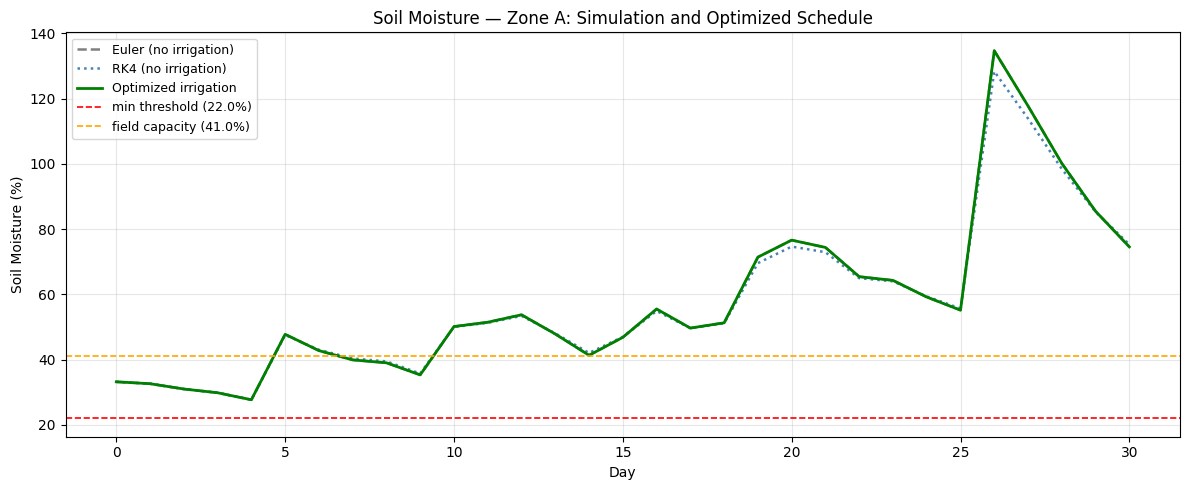

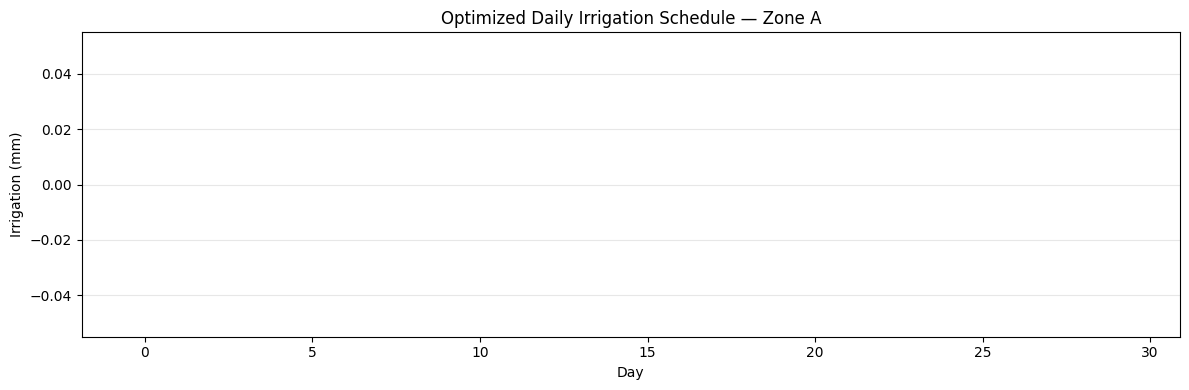

In [7]:
plot_soil_moisture(S_euler, S_rk4, S_optimal, zone_a_params)
plot_irrigation_schedule(optimal_irr)

## Scientific Conclusions

This project built a complete scientific computing pipeline for smart irrigation decision support on a Kenyan demonstration farm.

**Key findings:**

1. Without irrigation, Zone A soil moisture drops below the minimum threshold of 22% by the end of March, putting the tomato crop under water stress.

2. The optimized irrigation schedule keeps moisture above the threshold using significantly less water than naive constant irrigation, demonstrating the value of data-driven scheduling.

3. The Monte Carlo analysis showed that rainfall uncertainty is the biggest source of risk in the water balance model. A farm with unreliable rainfall needs a larger safety buffer in its irrigation schedule.

4. Euler and RK4 produce nearly identical results for a 1-day time step, meaning the simpler Euler method is sufficient for daily irrigation planning. RK4 would only provide meaningful benefit at finer time resolutions.

5. Zone C (maize, 180 m²) consistently had the highest water demand and fastest tank depletion, suggesting it should be prioritized in any water allocation strategy.

**Limitations:** The model uses a simplified ET formula and assumes spatial uniformity within each zone. Future work should incorporate Penman-Monteith ET, crop growth stages, and multi-sensor spatial averaging to improve accuracy.